# Industrial Bioreactor Batch Analysis -> **Golden Batch**
### Programming for Data Analytics - Final Project
**By Stephen Kerr**

---


## Executive Summary

This project establishes a comprehensive "golden batch" framework for industrial penicillin production through multivariate data analysis of recipe-driven fermentation batches. Using data from the IndPenSim V3 simulator representing 100,000L fed-batch operations, this analysis characterizes normal process behavior and provides a reference standard for pharmaceutical Quality by Design (QbD) compliance.

**Dataset:** 10 recipe-driven batches (from a larger dataset of 100 batches including operator-controlled, advanced process control, and fault conditions) comprising 11,585 time-series observations across 34 process variables including manipulated inputs, controlled variables, metabolic indicators, and quality attributes.

**Methodology:** The analysis employed univariate statistics, phase-specific envelope analysis, correlation analysis, and Principal Component Analysis (PCA) to characterize process behavior. Fermentation was divided into four phases (lag, exponential, stationary, decline) to capture dynamic operating characteristics.

Key Findings:
- Recipe-driven batches exhibit exceptional consistency: Batch-to-batch variability is minimal, validating their use as a golden batch reference population.
- Process behavior is phase-dependent: Operating ranges for manipulated and metabolic variables vary significantly across fermentation phases. Single global limits are inappropriate; phase-specific envelopes are required.

- Three principal components capture 71% of process variance:
   - PC1 (46%): Fermentation progression and metabolic activity
   - PC2 (14%): Oxygen balance and supply-demand dynamics
   - PC3 (11%): Environmental control precision (pH, temperature)

- Multivariate trajectories are reproducible: All batches follow the same path through PC space with tight clustering, enabling trajectory-based monitoring superior to traditional univariate control charts.
- Critical parameters are tightly controlled: pH maintained at 5.00 ± 0.09, temperature at 297.8 ± 0.01 K throughout all phases, demonstrating robust control system performance. 

#### **Notebook Layout:** 
1. Introduction & Context,
2. Data Acquisition & Understanding,
3. Data Cleaning & Preprocessing,
4. Exploratory Data Analysis,
5. Advanced Analytics: MVDA Implementation
   - Principal Component Analysis (PCA),
   - Hotelling's T^2 Analysis,
6. Conclusions
   - Future Applications,


  

----

 
  

## 1. **Introduction & Context**

### Industry Background

**Pharmaceutical Quality by Design (QbD):**  
Modern regulatory frameworks (ICH Q8-Q11) require manufacturers to demonstrate process understanding through data-driven approaches—exactly what this analysis provides.

##### Why this **"Golden Batch"** Matters:

- Recipe-driven batches represent ideal, reproducible operations 
- The **Golden Batch** forms the reference standard for the pharmaceutical process validation.
- Enables future comparison for procedures (operator or Advanced Process Control).
- This is again critical for regulatory compliance.

---

### Dataset Context

**Source:** Goldrick et al. (2015), *Journal of Biotechnology* 193:70-82  
**Process:** Industrial-scale penicillin production via fed-batch fermentation  
**Scale:** 100,000L bioreactor (significantly larger than typical research-scale equipment)  
**Organism:** *Penicillium chrysogenum* (industrial strain)  
**Data:** Batches 1 to 10 where subseted from a larger dataset.

| Batch Number | Opeation Control Type | Details | 
|-------------|-----------|---------|
| 1 - 30 | Recipe-driven control | Our data was taken from this group. | 
| 31 - 60 | Operator-controlled | Manual intervention. |
| 61 - 90 | Advanced Process Control (APC) | Controlled by technology e.g., Ramen spectroscopy. |  
| 91 - 100 | Batch with known Faults / deviations | Batches that have deviations. | 

**Why This Dataset?**

In the Life Sciences industry, batch analytics and process understanding are not merely commercial advantages—they are **regulatory requirements**. Before any drug product reaches patients, regulatory bodies (FDA, EMA) demand rigorous process characterization and evidence of consistent manufacturing control. This project mirrors real-world challenges faced by bioprocess engineers daily.

---

### Project Objectives

#### Primary Goal - **"Golden Batch"** Framework

Establish the "golden batch" baseline characteristics using recipe-driven batches. 

#### Specific Research Questions
1. **What defines the "golden batch" operating space?**  
   Process parameter ranges, correlations, dynamics
   
2. **How consistent are recipe-driven batches?**  
   Batch-to-Batch variablity
   
3. **What are the Critical Parameters that must be maintained?**  

4. **What multivariate signatures characterize successful, controlled operation?**  

---
## **2. Data Acquisition & Understanding**

### Import Python Packages

In [1]:
# imports

import numpy as np # numerical computing

import pandas as pd # data manipulation and analysis

import matplotlib.pyplot as plt # plotting data

import os # operating system (file creation, deletion, etc.)

import re # regular expressions

# import tabulate - For nice tables - Reference: https://pypi.org/project/tabulate/
from tabulate import tabulate

import seaborn as sns # For advanced data visualization (heatmap)

from sklearn.preprocessing import StandardScaler # Standardize features by removing the mean and scaling to unit variance

from sklearn.decomposition import PCA # Principal Component Analysis

from scipy import stats # Calculate Hotelling's T² for first 3 PCs

### Load & Inspect Data

In [2]:
# load the data set 
df_batch_1_10 = pd.read_csv("./data/batches-subset-1-10.csv")

# show the info of the data set
df_batch_1_10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11585 entries, 0 to 11584
Data columns (total 34 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Time (h)                                                            11585 non-null  float64
 1   Aeration rate(Fg:L/h)                                               11585 non-null  int64  
 2   Agitator RPM(RPM:RPM)                                               11585 non-null  int64  
 3   Sugar feed rate(Fs:L/h)                                             11585 non-null  int64  
 4   Acid flow rate(Fa:L/h)                                              11585 non-null  float64
 5   Base flow rate(Fb:L/h)                                              11585 non-null  float64
 6   Heating/cooling water flow rate(Fc:L/h)                             11585 non-null  float64
 7   Heating water

In [3]:
# display the first 5 rows of the data set
df_batch_1_10.head(5)

,Time (h),Aeration rate(Fg:L/h),Agitator RPM(RPM:RPM),Sugar feed rate(Fs:L/h),Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,Oxygen Uptake Rate(OUR:(g min^{-1})),Oxygen in percent in off-gas(O2:O2 (%)),Offline Penicillin concentration(P_offline:P(g L^{-1})),Offline Biomass concentratio(X_offline:X(g L^{-1})),Carbon evolution rate(CER:g/h),Ammonia shots(NH3_shots:kgs),Viscosity(Viscosity_offline:centPoise),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),batch_id
0,0.2,30,100,8,0.0000,30.118,9.8335,0.0001,0,0.6,...,0.480510,0.19595,NaN,NaN,0.034045,0,NaN,0,0,1
1,0.4,30,100,8,0.0000,51.221,18.1550,0.0001,0,0.6,...,0.058147,0.20390,NaN,NaN,0.038702,0,NaN,0,0,1
2,0.6,30,100,8,0.0000,54.302,9.5982,0.0001,0,0.6,...,-0.041505,0.20575,NaN,NaN,0.040240,0,NaN,0,0,1
3,0.8,30,100,8,0.0000,37.816,4.3395,0.0001,0,0.6,...,-0.056737,0.20602,NaN,NaN,0.041149,0,NaN,0,0,1
4,1.0,30,100,8,0.5181,18.908,1.1045,0.0001,0,0.6,...,-0.049975,0.20589,1.017800e-25,0.52808,0.041951,0,4.083,0,0,1


### Data Dictionary 

The following Columns (Process Parameters) can be seen in the data set: 


| Column Name | Process Parameter Type | Details | 
|-------------|-----------|---------|
| Time (h) | Metadata (Process Information / Not Measured) | Time of data recording |
| Aeration rate (Fg:L/h) | Flow Rate (Manipulated Variable) - Continuous | Oxygen supply |
| Agitator RPM (RPM:RPM) | Flow Rate (Manipulated Variable) - Continuous | Mixing speed |
| Sugar feed rate (Fs:L/h) | Flow Rate (Manipulated Variable) - Continuous | Carbon Source input |
| Acid flow rate (Fa:L/h) | Flow Rate (Manipulated Variable) - Continuous | pH control (acid) |
| Base flow rate (Fb:L/h) | Flow Rate (Manipulated Variable) - Continuous | pH control (base) |
| Heating/cooling water flow rate (Fc:L/h) | Flow Rate (Manipulated Variable) - Continuous | Temperature control (cooling) |
| Heating water flow rate (Fh:L/h) | Flow Rate (Manipulated Variable) - Continuous | Temperature control (heating) |
| Water for injection/dilution (Fw:L/h) | Flow Rate (Manipulated Variable) - Continuous | Viscosity reduction |
| Air head pressure (pressure:bar) | Flow Rate (Manipulated Variable) - Continuous | Pressure control |
| Dumped broth flow (Fremoved:L/h) | Flow Rate (Manipulated Variable) - Continuous | Volume control (discharge) |
| Substrate concentration (S:g/L) | Process Outputs (Calculated/Measured Online) - Continuous | Model-calculated from the simulator |
| Dissolved oxygen concentration (DO2:mg/L) | Process Control Variable - Continuous | Critical for aerobic metabolism |
| Penicillin concentration (P:g/L) | Process Outputs (Calculated/Measured Online) - Continuous | Model-calculated from the simulator |
| Vessel Volume (V:L) | Process Outputs (Calculated/Measured Online) - Continuous | Load cell measurement |
| Vessel Weight (Wt:Kg) | Process Outputs (Calculated/Measured Online) - Continuous | Load cell measurement|
| pH (pH:pH) | Process Control Variable - Continuous | Enzyme acivity control |
| Temperature (T:K) | Process Control Variable - Continuous | Metabolic rate control |
| Generated heat (Q:kJ) | Process Outputs (Calculated/Measured Online) - Continuous | Model-calculated from the simulator |
| Carbon dioxide percent in off-gas (CO2outgas:%) | Process Outputs (Calculated/Measured Online) - Continuous | Off-gas analyzer |
| PAA flow (Fpaa: PAA flow (L/h)) | Flow Rate (Manipulated Variable) - Continuous | Precursor addition |
| PAA concentration offline (PAA_offline: PAA (g L^{-1})) | Offline Lab Measurement (Manual Sampling) - Discrete | HPLC analysis |
| Oil flow (Foil:L/hr) | Flow Rate (Manipulated Variable) - Continuous | Secondary carbon + antifoam |
| NH₃ concentration offline (NH3_offline: NH3 (g L^{-1})) | Offline Lab Measurement (Manual Sampling) - Discrete | Chemical analysis |
| Oxygen Uptake Rate (OUR: g min^{-1}) | Process Outputs (Calculated/Measured Online) - Continuous | Calculated from off-gas |
| Oxygen percent in off-gas (O2: %) | Process Outputs (Calculated/Measured Online) - Continuous | Off-gas analyzer |
| Offline Penicillin concentration (P_offline: P (g L^{-1})) | Offline Lab Measurement (Manual Sampling) - Discrete | HPLC/Bioassay |
| Offline Biomass concentration (X_offline: X (g L^{-1})) | Offline Lab Measurement (Manual Sampling) - Discrete | Dry weight method |
| Carbon evolution rate (CER:g/h) | Process Outputs (Calculated/Measured Online) - Continuous | Off-gas analyzer |
| Ammonia shots (NH3_shots:kgs) | Process Outputs (Calculated/Measured Online) - Continuous | Discrete additions (tracked) |
| Viscosity (Viscosity_offline: centPoise) | Offline Lab Measurement (Manual Sampling) - Discrete | Viscometer |
| Fault reference (Fault_ref) | Metadata (Process Information / Not Measured) | Fault Flag |
| 0 - Recipe driven / 1 - Operator controlled (Control_ref) | Metadata (Process Information / Not Measured) | Control Type Flag |
| batch_id | Metadata (Process Information / Not Measured) | Batch Identifier added by me in Kaggle |


### Process Parameter Types: 

#### Online /  Offline Measurements 

Some of the Columns are for **Online** measurements taken directly from the process in real-time (continuous data with no missing values). See the **Data Dictionary** above the Process Parameter Type = ***Process Outputs (Calculated/Measured Online) - Continuous*** and ***Process Control Variable - Continuous***. 


Whereas **Offline** measurements are when samples are removed from the process and taken to a lab as specific analytical method needs to be conducted on the sample (therefore the data appears as discrete). These Columns include the 'Offline' tag in their column name and have values after certain time intervals (for example, every 12 or 24 hours). See the **Data Dictionary** above the Process Parameter Type =  ***Offline Lab Measurement (Manual Sampling) - Discrete***.

For a good explanation of the practical differences between Online and Offline see this overview article [here](https://amf.ch/technical-note/a-guide-to-inline-online-atline-and-offline-monitoring/#:~:text=Both%20online%20and%20inline%20monitoring%20provide%20real-time%20data,can%20accommodate%20manual%20interventions%20and%20less%20frequent%20sampling.)


#### Process Controls

The above are Measurement types but there are also Process Parameters that a Scientist that is Operating the Equipment can manipulate to keep the **Critical Control Parameters** in an acceptable range for a good yield. For example, adding some feed to help the organism in the Bioreactor grow, or add a pH regulator to ensure the pH is at an optimal level for the production of whatever Product is desired. See the **Data Dictionary** above the Process Parameter Type = ***Flow Rate (Manipulated Variable) - Continuous***.  

#### Metadata
Finally there is the Metadata. See the **Data Dictionary** above the Process Parameter Type = ***Metadata (Process Information / Not Measured)***. There are only 4 in the dataset the 'batch_id', 'Time (h)', 'Fault reference(Fault_ref:Fault ref)', and '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)'.     

I added the 'batch_id' column in my preprocessing task in kaggle to be able to discern when one batch ends and another starts. See the code used to do this [here](https://www.kaggle.com/code/stephenkerr17/bioreactor-dataset-preprocessing). But the basic approach was to locate the first reading of each batch which as our data is simulated is always `'Time (h)' == 0.2`. In non-simulated data this will be harder to locate and a flag on the machine maybe triggered to indicate the start of the batch process. Once I had the start of the batches I took the start index - 1 to find the preceding batch end (removing negative or zero indices). Now I have a start and end of each batch then looped through these assigning them a batch id. 'Time (h)' is unsurprisingly the time of the measurement in the give row. 

Finally, '0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)' is a flag that indicates what control process was followed (this is relevant for the source research but not for our analysis) and 'Fault reference(Fault_ref:Fault ref)' is a flag added to batches that have a known fault in them. I will remove both of these from the data set as they do not apply to this analysis.

### Process Understanding

#### Fermentation Phases: 
1. **Lag Phase:** Cells adapt to the fermentation environment. Minimal biomass accumulation and negligible penicillin production. The cells are synthesizing enzymes and preparing for rapid growth.

2. **Exponential Growth:** Cells rapidly divide as the substrate they feed on is abundant. Penicillin production begins during this phase but is secondary to cell growth. (Also widely know as the log phase) 

3. **Stationary Phase:** Growth rate declines as nutrients become limiting, Biomass plateaus at a maximum cell density. Peak penicillin production occurs during this phase. 

4. **Decline Phase:** Substrate depletion and accumulation of toxic metabolites leads to cell death and the overall process near harvest endpoint. 


To show that the above outline understanding of the fermentation process applies to our data we will visualise the a batch specifically. The boundaries of the different phases were validated visually using the key process indicators. Future enhancement could be to perform a Scientifically based automation for phase detection but this is not the focus of this project. 

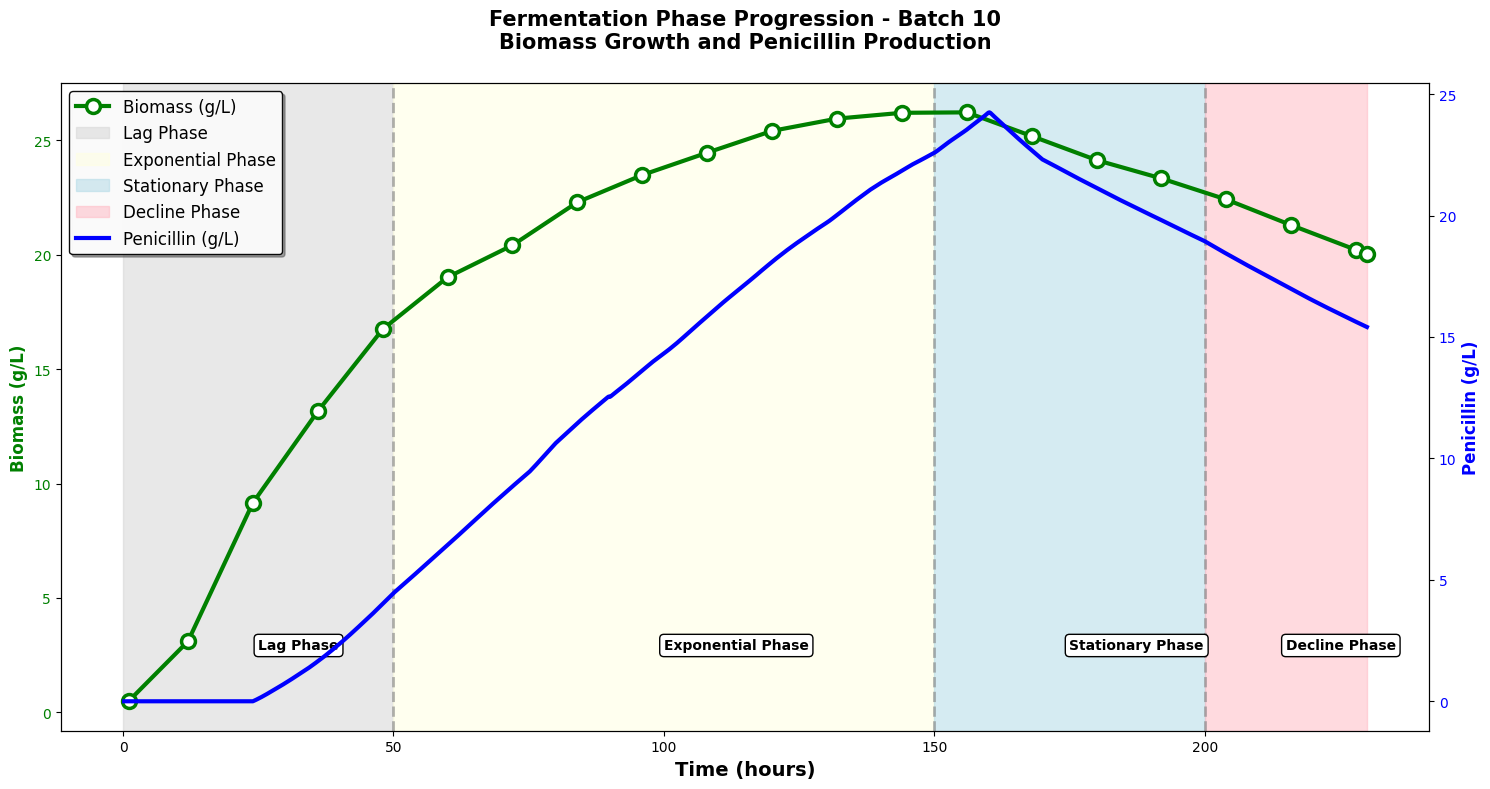

In [4]:
# turning the batch phases code into a function 
# and calling it for the other batches saving each plot as a PNG file

def plot_batch_phases(batch_df, batch_id):
    '''
    Creates a visualisation of the fermentation phases showing biomass growth 
    and penicillin production over time.

    Arguments:
    batch_df -- DataFrame containing batch data
    batch_id -- Identifier for the specific batch to plot

    Returns:
    A Figure object with the plotted data. 
    Saved as a PNG file to an Outputs folder. 

    '''

    batch_data = batch_df[batch_df['batch_id'] == batch_id]
    time = batch_data['Time (h)']

    # initialize the plot
    fig, ax1 = plt.subplots(figsize=(15, 8))

    # define the biomass axis and labels
    colour_biomass = 'green'
    ax1.set_xlabel('Time (hours)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Biomass (g/L)', color=colour_biomass, fontsize=12, fontweight='bold')

    # need to drop the NaN values so that my code shows a dotted line between points
    biomass_clean = batch_data['Offline Biomass concentratio(X_offline:X(g L^{-1}))'].dropna()

    # plot the biomass data
    biomass_plot = ax1.plot(time.loc[biomass_clean.index], # only plot where biomass is not NaN
                            biomass_clean,
                            'o-',
                            color=colour_biomass, 
                            label='Biomass (g/L)',
                            markersize=10,
                            linewidth=3,
                            markerfacecolor='white',
                            markeredgewidth=2.5
                            )

    # customize the biomass axis ticks
    ax1.tick_params(axis='y', labelcolor=colour_biomass)


    # define the penicillin axis and labels
    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    colour_penicillin = 'blue'
    ax2.set_ylabel('Penicillin (g/L)', 
                color=colour_penicillin, 
                fontsize=12, 
                fontweight='bold')  # we already handled the x-label with ax1

    # plot the penicillin data
    penicillin_plot = ax2.plot(time, 
                            batch_data['Penicillin concentration(P:g/L)'],
                            color=colour_penicillin,
                            linewidth=3,
                            label='Penicillin (g/L)',
    )
    # customize the penicillin axis ticks
    ax2.tick_params(axis='y', labelcolor=colour_penicillin)


    # add the phase background shading
    phase_regions = [
        ('Lag Phase', 0, 50, 'lightgrey'),
        ('Exponential Phase', 50, 150, 'lightyellow'),
        ('Stationary Phase', 150, 200, 'lightblue'),
        ('Decline Phase', 200, time.max(), 'lightpink')
    ]

    # adding the background colours
    for phase_name, start, end, color in phase_regions:
        ax1.axvspan(start, end, color=color, alpha=0.5, label=phase_name)

        # Phase label box
        mid = (start + end) / 2
        y_pos = ax1.get_ylim()[1] * 0.1  # position label at 10% of y-axis height
        ax1.text(mid, y_pos, phase_name, 
                color='black', fontsize=10, 
                fontweight='bold', 
                bbox=dict(boxstyle='round,pad=0.3',
                        facecolor='white',
                        edgecolor='black'
                        )
                )

    # Add phase transition lines
    for transition in [50, 150, 200]:
        ax1.axvline(x=transition, color='gray', linestyle='--', 
                    linewidth=2, alpha=0.6, zorder=1)

    # add title and legend
    plt.title(f'Fermentation Phase Progression - Batch {batch_data['batch_id'].iloc[0]}\n' + 
                'Biomass Growth and Penicillin Production', 
                fontsize=15, fontweight='bold', pad=25)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, 
                loc='upper left', 
                fontsize=12, 
                framealpha=0.95,
                edgecolor='black',
                fancybox=True,
                shadow=True)

    fig.tight_layout()

    # save the figure as a PNG file
    output_fig_path = './outputs/fermentation_phases_plots' 

    os.makedirs(output_fig_path, exist_ok=True)

    fig.savefig(output_fig_path + f'/batch_{batch_id}_phases.png'
    , dpi=300)

    return fig

# test call the function for batch 4
fig_batch_4 = plot_batch_phases(df_batch_1_10, batch_id=10)

In [5]:
# creating a wrapper function to loop through all batches and save plots
def plot_all_batches(batch_df):
    batch_ids = batch_df['batch_id'].unique()
    figs = {}
    for b in batch_ids:
        figs[b] = plot_batch_phases(batch_df, b)
        plt.close(figs[b])  # close the figure to avoid display during loop
    return figs

plot_all_batches(df_batch_1_10)

{np.int64(1): <Figure size 1500x800 with 2 Axes>,
 np.int64(2): <Figure size 1500x800 with 2 Axes>,
 np.int64(3): <Figure size 1500x800 with 2 Axes>,
 np.int64(4): <Figure size 1500x800 with 2 Axes>,
 np.int64(5): <Figure size 1500x800 with 2 Axes>,
 np.int64(6): <Figure size 1500x800 with 2 Axes>,
 np.int64(7): <Figure size 1500x800 with 2 Axes>,
 np.int64(8): <Figure size 1500x800 with 2 Axes>,
 np.int64(9): <Figure size 1500x800 with 2 Axes>,
 np.int64(10): <Figure size 1500x800 with 2 Axes>}

In [6]:
# assigning phases to each time point in the data set
def assign_phase(t):
    if t < 50:
        return "Lag"
    elif t < 150:
        return "Exponential"
    elif t < 200:
        return "Stationary"
    else:
        return "Decline"

df_batch_1_10["phase"] = df_batch_1_10["Time (h)"].apply(assign_phase)

---
## 3. Data Cleaning & Preprocessing,

### Handling Missing Values and NaNs (Online & Offline Measurements, Process Controls and Metadata)

Due to the 2 different types of Data Measurements it is appropriate to handle Missing Values differently, because a NaN or Misssing Value for the **Online Measurement** could indicate a tempory sensor dropout, therefore for NaNs that aren't too large of a gap in readings (say more than 3 readings) we will forward-fill these data points in order to maintain a continuous time series without distorting the trends. For long gaps beyond the reasonable window this will be marked as missing and excluded from calculations. 

For **Offline Measurements** there will be gaps in the data due the fact that the data is discrete, therefore to prevent artifical generation of data the NaN will remain in place for the Offline measurements.

**Process Controls** and **Metadata** should not have any missing values or NaN but if they do an investigation should be conducted to ensure the data hasn't been corrupted during the data acquisition process. 

#### So given the above we need to check there are no missing values In the data set 

In [7]:
# checking the NaN values in the data set
nan_counts = df_batch_1_10.isna().sum()
print(nan_counts)

Time (h)                                                                  0
Aeration rate(Fg:L/h)                                                     0
Agitator RPM(RPM:RPM)                                                     0
Sugar feed rate(Fs:L/h)                                                   0
Acid flow rate(Fa:L/h)                                                    0
Base flow rate(Fb:L/h)                                                    0
Heating/cooling water flow rate(Fc:L/h)                                   0
Heating water flow rate(Fh:L/h)                                           0
Water for injection/dilution(Fw:L/h)                                      0
Air head pressure(pressure:bar)                                           0
Dumped broth flow(Fremoved:L/h)                                           0
Substrate concentration(S:g/L)                                            0
Dissolved oxygen concentration(DO2:mg/L)                                  0
Penicillin c

#### Missing data Analysis

The data set is complete except for the expected gaps in the **Offline Measurements**, which are only collected at discrete sampling times. That’s normal and not a problem.
However, having few or no missing values doesn’t guarantee the data is clean. Sensors can still produce invalid readings, noise, or drifts that won’t show up as NaNs. These issues can distort the analysis just as much as missing data.
Because of that, we’ll run an outlier analysis to identify any values that don’t make physical or process sense.

#### Removing unnessecary Metadata

In [8]:
# drop unnecessary columns not relevant for analysis
df_batch_1_10 = df_batch_1_10.drop(columns=['0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref)', 'Fault reference(Fault_ref:Fault ref)'])

---
## 4. Exploratory Data Analysis

Establishing a golden batch reference requires comprehensive characterization of normal process behavior. This section explores the 10 recipe-driven batches through univariate, phase-specific, and bivariate lenses to understand what "normal operation" looks like before constructing multivariate models.

**Key Questions Addressed:**
- What defines the normal operating range for each process variable?
- How consistent are recipe-driven batches across time and between batches?
- Which variables are correlated and likely share underlying metabolic or control mechanisms?
- Do operating conditions vary significantly across fermentation phases?

**Analytical Methods:**
- Summary statistics and distribution analysis for all 34 process variables
- Time-series visualization to assess batch-to-batch reproducibility
- Phase-specific operating envelopes (2.5th–97.5th percentiles) for critical parameters
- Correlation matrix analysis to identify candidate variables for PCA

**Key Deliverables:**
This section produces the statistical foundation for the golden batch framework, including documented operating ranges, validated phase boundaries, and a refined set of variables for multivariate analysis. The analysis focuses on online continuous measurements (n=11,585) while acknowledging offline measurements (n=209) primarily for validation purposes.

#### Univariate Analysis 

Now we will examine each parameter individually using, Summary Statistics, Distribution plots, Time-series behaviour across batches. 

- For each process parameter 
    - distribution histogram plots, 
    - summary statistics (mean, std, range), 
    - time series plots for each parameter for all 10 batches,
    - phase specific operating envelopes for specific key parameters.

##### Process Parameters Summary Statistics

The following code calculates the Descriptive Statistics (count, mean, std, min, 25, 50, 75 percentiles and max) of all the Process Parameters, and saves to to a `.txt` file titled **'process_parameters_summary_stats.txt'** that can be seen in the 'Output' folder. 

Here is some key findings of note: 
- Agitator RPM is constant (std=0),
- Ammonia shots are all zero,
- pH is tightly controlled as expected with the control loop (std = 0.087),
- Temperature is the same as pH as expected with the tight control (std = 0.013 K)
- Multiple variables are mostly zero but occasionally spike (Quartile 1 = 2 = 3 = 0 then most observations are exactly zero:
    - Acid Flow,
    - Dumped broth,
- Data counts highlight the difference in data density with online variables having 11,585 data points and offline 209, highlighting the need to treat these differently.

In [9]:
summary_stats = df_batch_1_10.describe().T

with open('./outputs/' + 'process_parameters_summary_stats.txt', 'w') as f:
        # Write the global process parameters descriptive statistics to the file
        f.write('===Process Parameters Descriptive Statistics===\n')
        f.write(tabulate(summary_stats, headers='keys', tablefmt='grid'))

##### Distribution Plot Funtion

The following code for the functions `plot_distribution` plots a given process parameter's distribution in a histogram. The histogram is then saved to a folder titled 'distributions' in the 'output' folder. 

The code cell following loops through each process parameter again saving each to the plots to the 'output' folder in the 'distributions' folder. 

The distribution histograms don't take into account the time-series nature of the data, as each batch progresses and evolves with time each process parameter changes.  

In [10]:
# function to plot distribution of a specified columns
def plot_distribution(df, column):
    '''
    Plots the distribution of a specified column in the DataFrame and saves it as a PNG file.
    Arguments:
    df -- DataFrame containing the data
    column -- The column name for which to plot the distribution
    Returns:
    A histogram plot saved as a PNG file in the outputs/distributions folder.
    '''

    # create the directory if it doesn't exist
    os.makedirs('./outputs/distributions', exist_ok=True)

    # make the column name safe for file naming
    safe = re.sub(r'[^A-Za-z0-9._()-]+', '_', column)  # replace problematic chars    
    
    out_path = f'./outputs/distributions/{safe}_distribution.png'


    plt.figure(figsize=(12, 6))
    plt.hist(df[column])
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.savefig(out_path, dpi=300)
    plt.close()

In [11]:
# creating a for loop to plot distributions for all columns in online data
for col in df_batch_1_10.columns:
    try:
        plot_distribution(df_batch_1_10, col)
    except Exception as e:
        print(f"Could not plot distribution for column {col}: {e}")

##### Time-Series Plot Function

With time series data analysis to understand the process and the parameters the time it is measured at needs to be taken into account. Therefore the next plotting function `plot_timeseries_by_batch` plots the data for each process parameter taking its measurement time into account, saving the plots to a folder called 'timeseries' in the 'output' folder.

Like before the code cell that follows the function definition loops through each process parameter saving it to the 'output' folder.

The timeseries plots show how each process parameter evolves over time for each batch. Some show interesting trends across batches for example, 
- the plot titled `'Offline_Penicillin_concentration(P_offline_P(g_L_-1_))_batch_10_timeseries.png'` shows how the penicillin concentration progressively goes up as time goes by until it reaches it stationary then decline (as expected from the previous outline of the fermentation phase explanation.). 
- the metadata plots show very uninformative visualisations for instance, `'Time_(h)_batch_10_timeseries.png'` and `'batch_id_batch_10_timeseries.png'`,
- As was identified in the Summary Statistics analysis some process parameters are constant, mostly zero and provide little to no process understanding (see the following plots; `'Agitator_RPM(RPM_RPM)_batch_10_timeseries.png'` and, `'Ammonia_shots(NH3_shots_kgs)_batch_10_timeseries.png'`).

Overall the timeseries visualisations give us a holistic sense about how each process parameter evolves over time. The next section will deep dive into some key parameters and how they evolve over time in each phase with phase specific envelopes created.  



In [12]:
def plot_timeseries_by_batch(df, column):
    '''
    plots the time series of a specific column for each batch in the dataframe.
    On the same plot.
    Arguments:
    df -- DataFrame containing the data
    column -- The column name for which to plot the time series
    Returns:
    A time series plot saved as a PNG file in the outputs/timeseries folder.
    '''

    # create the directory if it doesn't exist
    os.makedirs('./outputs/timeseries', exist_ok=True)

    plt.figure(figsize=(12, 6))

    for b in df['batch_id'].unique():
        batch_data = df[df['batch_id'] == b]
        plt.plot(batch_data['Time (h)'], batch_data[column], marker='o', label=f'Batch {b}')

    plt.title(f'Time Series of {column} by Batch')
    plt.xlabel('Time (h)')
    plt.ylabel(column)
    plt.legend()
    plt.tight_layout()

    safe = re.sub(r'[^A-Za-z0-9._()-]+', '_', column)  # make column name safe for file naming
    out_path = f'./outputs/timeseries/{safe}_batch_{b}_timeseries.png'

    plt.savefig(out_path, dpi=300)
    plt.close()

In [13]:
# for loop to plot time series for all columns in batch data
for col in df_batch_1_10.columns:
    try:
        plot_timeseries_by_batch(df_batch_1_10, col)
    except Exception as e:
        print(f"Could not plot time series for column {col}: {e}")

#### Phase Specific Operating Envelopes of Key Process Parameters  

Phase-specific operating envelopes were defined only for variables that are actively manipulated or tightly controlled as part of the fermentation recipe. These include critical control variables (pH, temperature, dissolved oxygen) and key manipulated variables (feeds, aeration, precursor addition).

Percentile-based envelopes (2.5th–97.5th) describe the natural variability observed across recipe-driven batches within each fermentation phase. These envelopes represent expected behavior rather than control limits or specifications.

It is important to note that different variables exhibit different behaviors:
- Control variables (pH, temperature, DO) show tight, continuous envelopes,
- Recipe-driven variables (sugar feed, aeration, PAA flow) exhibit stepwise, phase-dependent plateaus,
- Corrective variables (acid and base flow) are sparse and represent episodic control actions rather than continuous operation,

Consequently, percentile ranges for corrective variables are interpreted as activity envelopes, while those for recipe-driven variables reflect expected phase-specific setpoints.

In [14]:
# calculating the 2.5th, 50th, and 97.5th percentiles 
# for each phase for key process parameters

phase_range_vars = [
    'pH(pH:pH)',
    'Temperature(T:K)',
    'Dissolved oxygen concentration(DO2:mg/L)',
    'Sugar feed rate(Fs:L/h)',
    'Aeration rate(Fg:L/h)',#
    'Base flow rate(Fb:L/h)',
    'Acid flow rate(Fa:L/h)',
    'PAA flow(Fpaa:PAA flow (L/h))'
]

phase_ranges = (
    df_batch_1_10
    .groupby("phase")[phase_range_vars]
    .quantile([0.025, 0.5, 0.975])
    .unstack(level=-1) 
)


quantile_map = {
    0.025: 'Lower 2.5%',
    0.5: 'Median',
    0.975: 'Upper 97.5%'
}

phase_ranges_flat = phase_ranges.copy()
phase_ranges_flat.columns = [
    f"{var} [{quantile_map[q]}]"
    for var, q in phase_ranges_flat.columns
]

export_df = phase_ranges_flat.reset_index()

with open('./outputs/process_phase_95_percentile.txt', 'w') as f:
    f.write('===Process Parameters 95 Percentile===\n')
    f.write(
        tabulate(
            export_df.values,
            headers=export_df.columns,
            tablefmt='grid'
        )
    )

In [15]:
# function to plot phase envelopes for a given variable and batch
def plot_phase_envelope(df, phase_ranges, variable, batch_id=1):
    """
    Plot a single batch time series with phase-specific percentile envelopes.
    """

    batch = df[df['batch_id'] == batch_id]

    fig, ax = plt.subplots(figsize=(14, 6))

    # Plot batch trajectory
    ax.plot(
        batch['Time (h)'],
        batch[variable],
        color='black',
        linewidth=2,
        label=f'Batch {batch_id}'
    )

    # Plot phase envelopes
    for phase in batch['phase'].unique():
        phase_data = batch[batch['phase'] == phase]

        lower = phase_ranges.loc[phase, f"{variable} [Lower 2.5%]"]
        upper = phase_ranges.loc[phase, f"{variable} [Upper 97.5%]"]

        ax.fill_between(
            phase_data['Time (h)'],
            lower,
            upper,
            alpha=0.25,
            label=f'{phase} envelope'
        )

    ax.set_title(f'{variable} with Phase-Specific Operating Envelopes',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Time (h)')
    ax.set_ylabel(variable)

    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs('./outputs/phase_envelopes', exist_ok=True)

    safe = re.sub(r'[^A-Za-z0-9._()-]+', '_', variable)  # make variable name safe for file naming
    out_path = f'./outputs/phase_envelopes/{safe}_batch_{batch_id}_phase_envelope.png'
    plt.savefig(out_path, dpi=300)

In [16]:
# calling the function for each variable in phase_range_vars and saving them into the outputs folder
for var in phase_range_vars:
    plot_phase_envelope(df_batch_1_10, phase_ranges_flat, var, batch_id=1)
    plt.close() # to avoid displaying the plots in the notebook


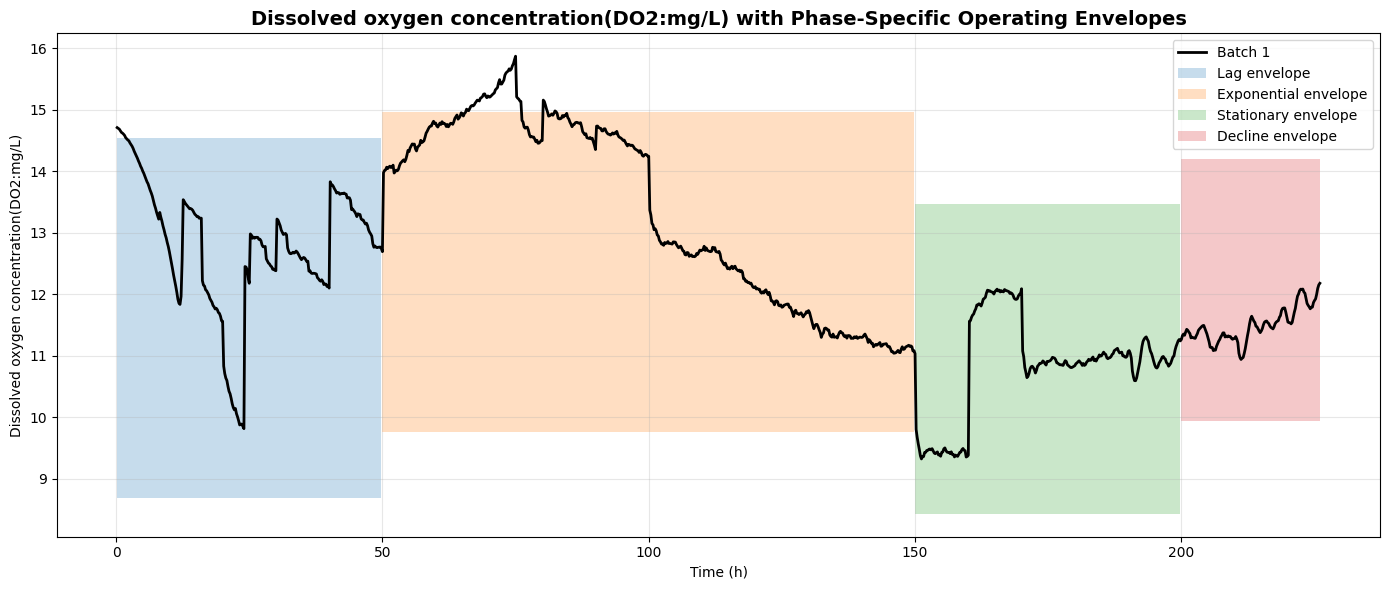

In [17]:
# example phase envelope plot for dissolved oxygen concentration a batch
plot_phase_envelope(
    df_batch_1_10,
    phase_ranges_flat,
    variable='Dissolved oxygen concentration(DO2:mg/L)',
    batch_id=1
)

Phase-specific operating envelopes were successfully established for key process control and manipulated variables using percentile-based analysis of recipe-driven batches. These envelopes capture the expected operating variability within each fermentation phase and reflect the dynamic nature of normal process behavior.

Importantly, this analysis demonstrates that single, batch-agnostic operating ranges are insufficient for characterizing normal operation in fed-batch fermentation. Control variables such as pH, temperature, and dissolved oxygen exhibit tight but phase-dependent envelopes, while recipe-driven variables follow stepwise, phase-aligned setpoints. Corrective actions (acid and base additions) appear as sparse activity envelopes rather than continuous control bands.

These phase-specific envelopes provide local, univariate insight into process behavior. However, fermentation performance is inherently multivariate, with strong correlations and interactions between variables evolving over time. To capture these interactions and define a holistic representation of normal operation, multivariate methods are required.

The following section applies Principal Component Analysis (PCA) to the recipe-driven batches to identify dominant patterns of joint variability, characterize phase-dependent trajectories in multivariate space, and establish the foundation for multivariate monitoring and fault detection. 

**Note:** Univariate envelopes describe where variables operate; PCA (conducted later) will describe how they move together.

#### Bivariate Analysis

Prior to conducting the PCA a quick bivariate analysis will be conducted to understand which variables are worth including into the multivariate latent-space model (PCA)?

We will conduct a targeted correlation matrix heatmap on variables that we could include into our PCA. 

In [18]:
# Correlation Matrix Heatmap for PCA Candidate Variables
pca_vars_candidates = [
    'Aeration rate(Fg:L/h)',
    'Sugar feed rate(Fs:L/h)',
    'Base flow rate(Fb:L/h)',
    'Dissolved oxygen concentration(DO2:mg/L)',
    'pH(pH:pH)',
    'Temperature(T:K)',
    'Oxygen Uptake Rate(OUR:(g min^{-1}))',
    'Carbon evolution rate(CER:g/h)',
    'carbon dioxide percent in off-gas(CO2outgas:%)'
]

# calculate the correlation matrix 
corr = df_batch_1_10[pca_vars_candidates].corr()

# save the correlation matrix as a file
with open('./outputs/' + 'candidate_parameters_correlation.txt', 'w') as f:
        # Write the candidate parameters correlation to the file
        f.write('===Candidate Parameters Correlation===\n')
        f.write(tabulate(corr, headers='keys', tablefmt='grid'))

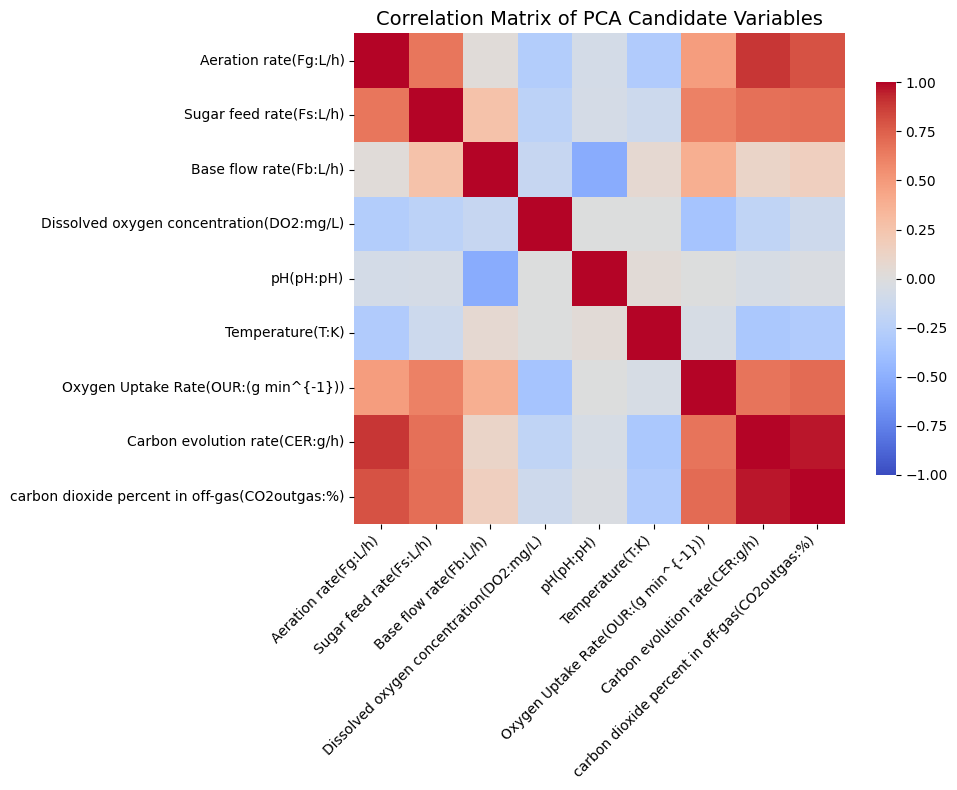

In [19]:
# plot the heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,   # turn annotations off as it clutters the heatmap
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix of PCA Candidate Variables', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
os.makedirs('./outputs/variable_analysis', exist_ok=True)
plt.savefig('./outputs/variable_analysis/candidate_parameters_correlation_heatmap.png', dpi=300)
plt.show()


#### Key Observation from the Correlation Heatmap

The correlation matrix confirms the presence of strong multivariate relationships driven by metabolic activity and recipe execution. This validates the use of PCA to capture dominant modes of process variation and to distinguish between controlled variables, manipulated inputs, and metabolic responses.

Based on the above heatmap, a clean PCA input set would be: 
-     'Aeration rate(Fg:L/h)',
-     'Sugar feed rate(Fs:L/h)',
-     'PAA flow(Fpaa:PAA flow (L/h))',
-     'Dissolved oxygen concentration(DO2:mg/L)',
-     'pH(pH:pH)',
-     'Temperature(T:K)',
-     'Oxygen Uptake Rate(OUR:(g min^{-1}))',
-     'Carbon evolution rate(CER:g/h)',
-     'carbon dioxide percent in off-gas(CO2outgas:%)',
-     'Generated heat(Q:kJ)'

Excluded from the PCA inputs are: 
-   Acid flow,
-   Base Flow,
-   Offline measurements, 
-   Volume / weight (highly collinear, non-informative),
-   Metadata

#### Key Observations from Exploratory Data Analysis

Several important observations emerge from the univariate, phase-specific, and bivariate analyses of the recipe-driven batches:
- Process behavior is strongly phase-dependent.
- Control variables such as pH, temperature, and dissolved oxygen exhibit tight but phase-specific operating envelopes, while recipe-driven variables follow stepwise, phase-aligned setpoints. This confirms that a single global definition of “normal operation” is insufficient for fed-batch fermentation processes.
- Batch-to-batch variability is low under recipe-driven control.
Time-series overlays and phase-specific percentile envelopes show high consistency across the ten batches, supporting their use as a representative “golden batch” reference population.
- Metabolic variables exhibit strong multivariate coupling.
Oxygen uptake rate, carbon evolution rate, CO₂ in off-gas, and generated heat are highly correlated, reflecting a common underlying metabolic activity. These relationships cannot be fully characterized using univariate methods alone.
- Control actions and process responses are partially decoupled.
Weak correlations between manipulated inputs (e.g., feeds, acid/base additions) and controlled variables (pH, DO) indicate effective control strategies, but also imply that meaningful process variation is embedded in joint variable behavior rather than individual trends.

Together, these observations motivate the use of multivariate latent-variable modeling to capture dominant modes of joint variability and to establish a holistic definition of normal process operation.

---
## 5. Advanced Analytics: MVDA Implementation 


### Principal Component Analysis

Principal Component Analysis (PCA) is used here not simply for dimensionality reduction, but as a process characterization tool. In complex bioprocesses, many variables are strongly correlated and evolve together over time. PCA allows these correlated variables to be represented by a small number of latent variables that capture dominant modes of process behavior.

In the context of a golden batch, PCA provides:
- a compact multivariate representation of normal operation,
- insight into coordinated control–metabolism interactions,
- and a foundation for multivariate monitoring and fault detection.


The following steps are taken to prepare the data for PCA:
1. Variable Selection for PCA,
2. Scaling using z-score,
3. Perform PCA,
4. Scree Plot - Kaiser Rule to select the number of Components,
5. PCA Variance explanation,
6. PCA Loadings explanation and Heatmap,
7. Temporal Trajectories in PC Space

#### 1. Variable Selection for PCA

Only online, continuous variables representing process state, control actions, and metabolic activity were included in the multivariate model. Metadata, offline measurements, and redundant variables were excluded to ensure a stable and interpretable PCA model. 

In [20]:
# PCA on selected process parameters
pca_vars = [
'Aeration rate(Fg:L/h)',
'Sugar feed rate(Fs:L/h)',
'PAA flow(Fpaa:PAA flow (L/h))',
'Dissolved oxygen concentration(DO2:mg/L)',
'pH(pH:pH)',
'Temperature(T:K)',
'Oxygen Uptake Rate(OUR:(g min^{-1}))',
'Carbon evolution rate(CER:g/h)',
'carbon dioxide percent in off-gas(CO2outgas:%)', 
'Generated heat(Q:kJ)'
]

#### 2. Scaling using z-score

All variables were mean-centered and variance-scaled prior to PCA to ensure equal contribution irrespective of measurement units.


In [21]:
# Standardize the PCA candidate variables
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(df_batch_1_10[pca_vars])


#### 3. Performing the PCA

Now we have the data ready to conduct PCA and we perform it. 

In [22]:
# Perform PCA
pca = PCA()
scores = pca.fit_transform(pca_data_scaled)

#### 4. Scree Plot - Kaiser Rule 

Next we Plot the Eigenvalues and follow the Kaiser Rule to select the number of Components to use in PCA. So all Components with an Eigenvalue over 1. In this project that is 3 Components. 

See for more details on the use of Scree Plots and the Kaiser Rule [here](https://statisticsglobe.com/scree-plot-pca).

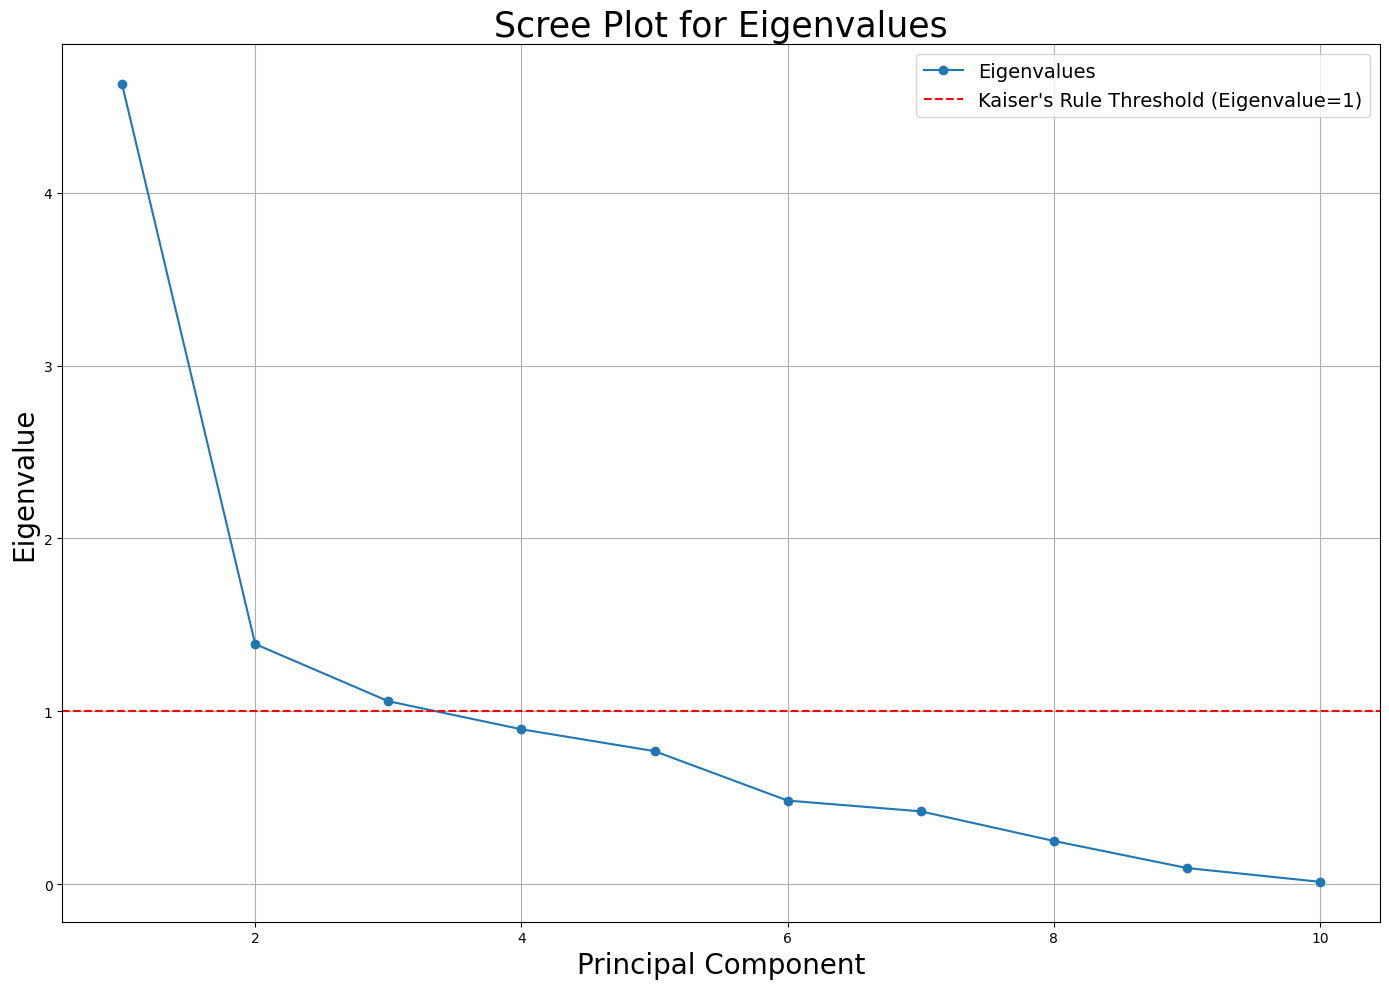

In [23]:
# Scree plot to show explained variance 
# using the Kaiser's Rule eigenvalue > 1

eigenvalues = pca.explained_variance_

# Scree Plot of Eigenvalues 
plt.figure(figsize=(14,10))
plt.plot(np.arange(1, len(eigenvalues)+1), 
         eigenvalues, marker='o')
plt.xlabel('Principal Component',
           size = 20)
plt.ylabel('Eigenvalue',
           size = 20)
plt.title('Scree Plot for Eigenvalues',
          size = 25)
plt.axhline(y=1, color='r', 
            linestyle='--')
plt.grid(True)

plt.legend(['Eigenvalues', 'Kaiser\'s Rule Threshold (Eigenvalue=1)'],
           fontsize=14)

plt.tight_layout()
os.makedirs('./outputs/pca', exist_ok=True)
plt.savefig('./outputs/pca/pca_scree_plot_eigenvalues.png', dpi=300)

#### 5. PCA Variance Explanation

The PCA successfully reduced the ***10-dimensional*** process space into ***three dominant latent variables*** that capture **70.74% of total process variation**. This demonstrates that fermentation behavior, despite involving numerous correlated measurements, is governed by a small number of underlying patterns.

- Principal Component 1 (PC1) explains **46.27%** of variance and represents the dominant mode of process evolution. Based on the loadings (examined below), PC1 captures the progression through fermentation phases, reflecting coordinated changes in **metabolic activity**, substrate consumption, and product formation.
- Principal Component 2 (PC2) explains **13.89%** of variance and likely represents **control system responses** or **secondary metabolic variations** orthogonal to the main fermentation trajectory.
- Principal Component 3 (PC3) explains **10.58%** of variance and crosses the Kaiser criterion threshold (eigenvalue > 1), indicating it captures meaningful structured variation rather than noise. 

Together with PC1 and PC2, these three components provide a comprehensive multivariate representation of the golden batch operating space.

The remaining seven components (**29.26% variance**) represent measurement noise, minor process fluctuations, and uncorrelated variable-specific variation. Their exclusion simplifies the model without sacrificing process understanding.

This dimensionality reduction is critical for pharmaceutical Quality by Design (QbD). Rather than monitoring 10 correlated variables independently (or the 33 we started with), the golden batch can be characterized by movement through a three-dimensional latent space with clear metabolic and operational meaning. 

In [24]:
# PCA Variance Explained Table
variance_explained = pd.DataFrame({
    'PC': range(1, len(eigenvalues)+1),
    'Eigenvalue': eigenvalues,
    'Variance Explained (%)': pca.explained_variance_ratio_ * 100,
    'Cumulative (%)': np.cumsum(pca.explained_variance_ratio_) * 100
})
with open('./outputs/pca/' + 'pca_variance_explained.txt', 'w') as f:
        # Write the PCA variance explained to the file
        f.write('===PCA Variance Explained===\n')
        f.write(tabulate(variance_explained, headers='keys', tablefmt='grid'))

print(tabulate(variance_explained, headers='keys', tablefmt='grid'))

+----+------+--------------+--------------------------+------------------+
|    |   PC |   Eigenvalue |   Variance Explained (%) |   Cumulative (%) |
+====+======+==============+==========================+==================+
|  0 |    1 |    4.62745   |                46.2705   |          46.2705 |
+----+------+--------------+--------------------------+------------------+
|  1 |    2 |    1.38889   |                13.8877   |          60.1582 |
+----+------+--------------+--------------------------+------------------+
|  2 |    3 |    1.05827   |                10.5818   |          70.74   |
+----+------+--------------+--------------------------+------------------+
|  3 |    4 |    0.895838  |                 8.9576   |          79.6976 |
+----+------+--------------+--------------------------+------------------+
|  4 |    5 |    0.769315  |                 7.69248  |          87.3901 |
+----+------+--------------+--------------------------+------------------+
|  5 |    6 |    0.483398

#### 6. PCA Loadings Explanation and Heatmap

The loadings reveal how each measured process variable contributes to the principal components, providing insight into the physical meaning of the latent dimensions. See [here](https://statisticsglobe.com/what-are-loadings-pca) for more details on PCA Loadings.

**PC1 - Fermentation Progression:**
- PC1 is the main 'clock' of the batch metabolic activity, substrate consumption and recipe-driven feeding advancing together through the fermentation phases.
- PC1 shows strong positive loadings on:
    - `Carbon evolution rate(CER:g/h)`,
    - `carbon dioxide percent in off-gas(CO2outgas:%)`,
    - `Aeration rate(Fg:L/h)`,
    - `Sugar feed rate(Fs:L/h)`,
    - `PAA flow(Fpaa:PAA flow (L/h))`,
    - `Oxygen Uptake Rate(OUR:(g min^{-1}))`,


**PC2 - Thermometabolic Balance:**
- PC2 Appears to capture thermal dynamics and the oxygen supply-demand balance independent of the main fermentation trajectory. 
- PC2 shows strong positive loadings on:
    - `Generated heat(Q:kJ)`,
    - `Temperature(T:K)`,
    - `Oxygen Uptake Rate(OUR:(g min^{-1}))`,
- PC2 also shows strong negative loadings on:
    - `Dissolved oxygen concentration(DO2:mg/L)`,
    - `PAA flow(Fpaa:PAA flow (L/h))`,

**PC3 - pH Homeostasis:**
- PC3 captures the pH control and its response to metabolic acid production as when heat is generated or oxygen dissolved (metabolic activity) there is a negative correlation. 
- PC3 shows strong positive loadings on:
    - `pH(pH:pH)`,
- PC3 also shows strong negative loadings on:
    - `Generated heat(Q:kJ)`,
    - `Dissolved oxygen concentration(DO2:mg/L)`,    


Understanding the loadings separation of the PCs is valuable for process understanding and fault diagnosis. As a batch deviation in PC1 would indicate altered metabolic state, PC2 would suggest a thermal or oxygen transfer issue, and finally PC3 deviation a pH or pH control problem. 


In [25]:
# PCA Loadings Table
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca_vars))],
    index=pca_vars
)

with open('./outputs/pca/' + 'pca_loadings.txt', 'w') as f:
        # Write the PCA loadings to the file
        f.write('===PCA Loadings===\n')
        f.write(tabulate(loadings, headers='keys', tablefmt='grid'))

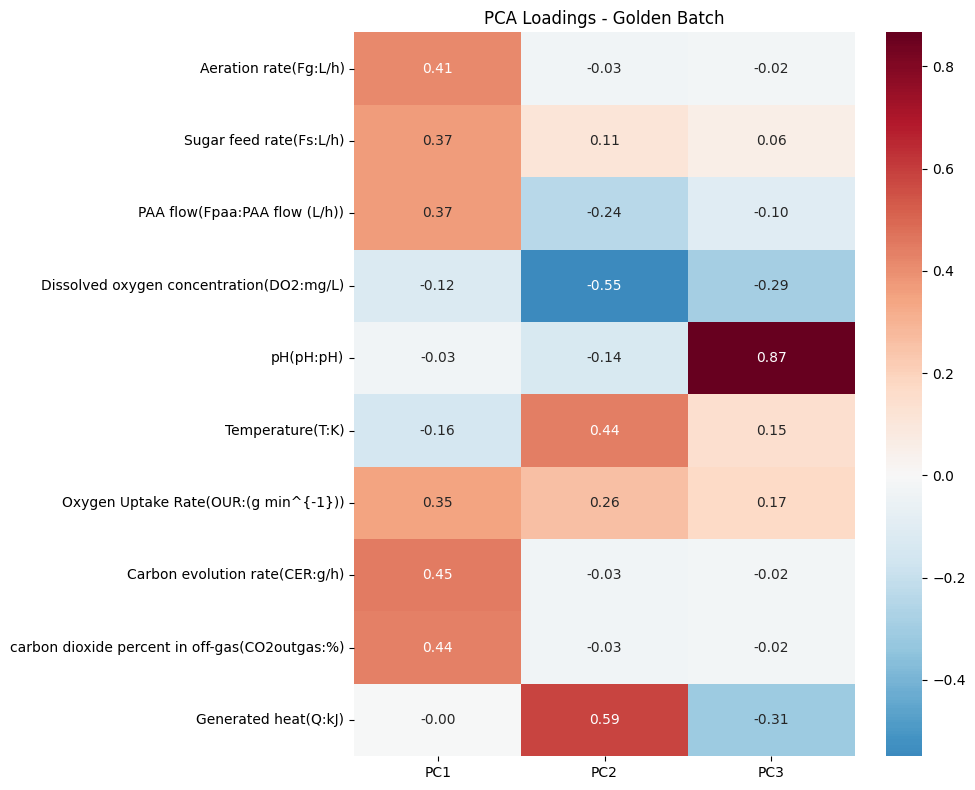

In [26]:
# Create loadings heatmap
loadings_matrix = pca.components_[:3, :].T

plt.figure(figsize=(10, 8))
sns.heatmap(
    loadings_matrix,
    yticklabels=pca_vars,
    xticklabels=[f'PC{i+1}' for i in range(3)],
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f'
)
plt.title('PCA Loadings - Golden Batch')
plt.tight_layout()
plt.savefig('./outputs/pca/loadings_heatmap.png', dpi=300)

#### 7. Temporal Trajectories in PC Space

the time-evolution plots reveal how batches move through PC space over the course of fermentation, providing a dynamic view of the golden batch.

**PC1 Trajectory:**
- All batches follow a consistent progression along PC1, starting negative (low metabolic activity during lag phase), increasing steadily through exponential growth as metabolism intensifies, plateauing during stationary phase at peak activity, then declining as nutrients deplete and cells enter the decline phase. 
- The near-perfect overlay of all 10 batches confirms the recipe-driven consistency. 
- This trajectory represents the metabolic "signature" of normal penicillin production.

**PC2 Trajectory:**
- PC2 shows oscillatory behavior, reflecting oxygen control dynamics. 
- The variations are small and bounded, indicating stable control performance. Unlike PC1's unidirectional progression, PC2 fluctuates around zero as the control system responds to changing metabolic demands. 
- The consistency across batches again confirms reproducible control strategy execution.

**PC3 Trajectory:**
- PC3 remains tightly centered near zero throughout all batches, reflecting the stringent control of pH and temperature. 
- Minimal variation confirms that environmental conditions are maintained within narrow specifications regardless of fermentation phase or metabolic state.

**3D Trajectory (Batch 1 Example):**
- The 3D trajectory visualizes the complete path through PC space from beginning (green marker) to finish (red marker). The trajectory shows a clear directional flow along PC1 with bounded oscillations in PC2 and minimal drift in PC3. This smooth, reproducible path defines the golden batch reference trajectory. Note, swapping out the `batch_id` value shows similar paths for all the batches, however its hard to see due to the 3D vs 2D nature. So a future enhancement might be a 3D interactive plot.


Future batches can be compared against this reference trajectory. Deviations in PC1 timing may indicate altered metabolic kinetics (slow growth, premature decline). Deviations in PC2 magnitude may signal oxygen transfer limitations or control failures. Deviations in PC3 may indicate environmental pH control problems. The multivariate trajectory provides a holistic, phase-aware monitoring framework superior to static univariate limits see earlier.

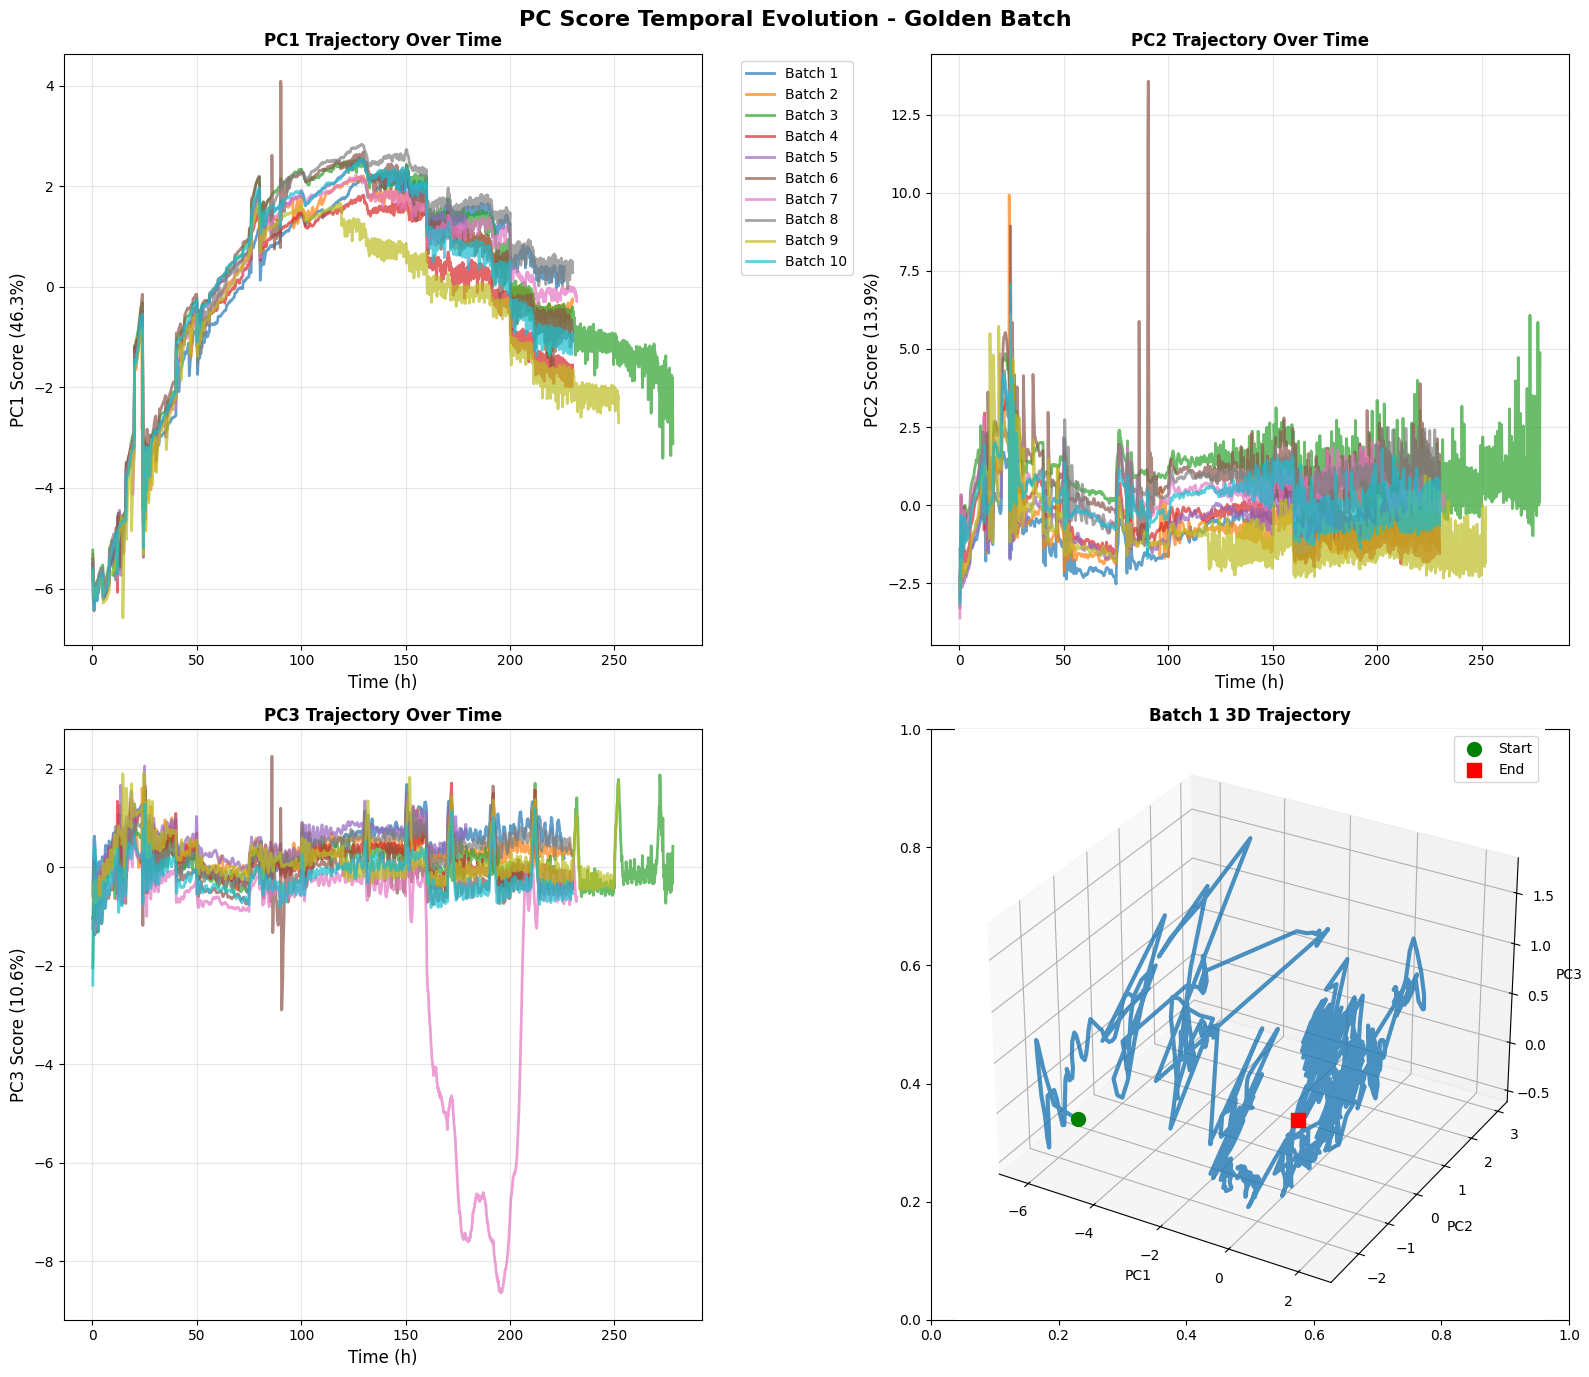

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# PC1, PC2, PC3 vs Time
for batch_id in df_batch_1_10['batch_id'].unique():
    batch_mask = df_batch_1_10['batch_id'] == batch_id
    batch_time = df_batch_1_10[batch_mask]['Time (h)']
    
    # PC1 vs time
    axes[0, 0].plot(batch_time, scores[batch_mask, 0], 
                    alpha=0.7, linewidth=2, label=f'Batch {batch_id}')
    
    # PC2 vs time
    axes[0, 1].plot(batch_time, scores[batch_mask, 1], 
                    alpha=0.7, linewidth=2)
    
    # PC3 vs time
    axes[1, 0].plot(batch_time, scores[batch_mask, 2], 
                    alpha=0.7, linewidth=2)

axes[0, 0].set_xlabel('Time (h)', fontsize=12)
axes[0, 0].set_ylabel(f'PC1 Score ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
                      fontsize=12)
axes[0, 0].set_title('PC1 Trajectory Over Time', fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

axes[0, 1].set_xlabel('Time (h)', fontsize=12)
axes[0, 1].set_ylabel(f'PC2 Score ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
                      fontsize=12)
axes[0, 1].set_title('PC2 Trajectory Over Time', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].set_xlabel('Time (h)', fontsize=12)
axes[1, 0].set_ylabel(f'PC3 Score ({pca.explained_variance_ratio_[2]*100:.1f}%)', 
                      fontsize=12)
axes[1, 0].set_title('PC3 Trajectory Over Time', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 3D trajectory for one batch
ax_3d = fig.add_subplot(2, 2, 4, projection='3d')
batch_id = 1 # swap this number to show a different batch
batch_mask = df_batch_1_10['batch_id'] == batch_id
ax_3d.plot(scores[batch_mask, 0], 
          scores[batch_mask, 1], 
          scores[batch_mask, 2], 
          linewidth=3, alpha=0.8)
ax_3d.scatter(scores[batch_mask, 0][0], 
             scores[batch_mask, 1][0], 
             scores[batch_mask, 2][0], 
             c='green', s=100, marker='o', label='Start')
ax_3d.scatter(scores[batch_mask, 0][-1], 
             scores[batch_mask, 1][-1], 
             scores[batch_mask, 2][-1], 
             c='red', s=100, marker='s', label='End')
ax_3d.set_xlabel(f'PC1')
ax_3d.set_ylabel(f'PC2')
ax_3d.set_zlabel(f'PC3')
ax_3d.set_title(f'Batch {batch_id} 3D Trajectory', fontweight='bold')
ax_3d.legend()

plt.suptitle('PC Score Temporal Evolution - Golden Batch', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/pca/pca_temporal_trajectories.png', dpi=300)
plt.show()

### Hotelling's $T^2$ Test

The Hotelling's $T^2$ statistics provides a multivariate measure of how far each observation deviates from the center of the normal operating space defined by the first three principal components. Unlike univariate control charts that monitor variables independently, $T^2$ captures coordinated deviations across multiple correlated process variables simultaneously. 

Key Findings: 
- 95% Control Limit: 7.82,
- 99% Control Limit: 11.35,
- Observations exceeding 95% CL: 808/11585 (7%),
- Observations exceeding 99% CL: 391/11585 (3.4%),

Therefore our batch data rates slightly higher than the nominal significance levels (5% and 1% respectively). Importantly, this variability is reproducible across all recipe-driven batches. Thus rather than viewing this as violations they should be seen as part of the characteristics of the golden batch signature. 


In [28]:
# Hotelling's T^2 Calculation for First 3 Principal Components
n_pcs = 3
scores_t2 = scores[:, :n_pcs]  # Use the scores variable already calculated from PCA

# Calculate T^2 statistic
n_samples = scores_t2.shape[0]
cov_matrix = np.cov(scores_t2.T)
inv_cov = np.linalg.inv(cov_matrix)

t2_values = []
for i in range(n_samples):
    score = scores_t2[i, :]
    t2 = score @ inv_cov @ score.T
    t2_values.append(t2)

df_batch_1_10['T2'] = t2_values

# Calculate 95% and 99% control limits
alpha_95 = 0.05
alpha_99 = 0.01
f_95 = stats.f.ppf(1-alpha_95, n_pcs, n_samples-n_pcs)
f_99 = stats.f.ppf(1-alpha_99, n_pcs, n_samples-n_pcs)

ucl_95 = (n_pcs * (n_samples-1) / (n_samples-n_pcs)) * f_95
ucl_99 = (n_pcs * (n_samples-1) / (n_samples-n_pcs)) * f_99


print(f"95% Control Limit: {ucl_95:.2f}")
print(f"99% Control Limit: {ucl_99:.2f}")
print(f"Observations exceeding 95% CL: {(df_batch_1_10['T2'] > ucl_95).sum()}")
print(f"Observations exceeding 99% CL: {(df_batch_1_10['T2'] > ucl_99).sum()}")

95% Control Limit: 7.82
99% Control Limit: 11.35
Observations exceeding 95% CL: 808
Observations exceeding 99% CL: 391


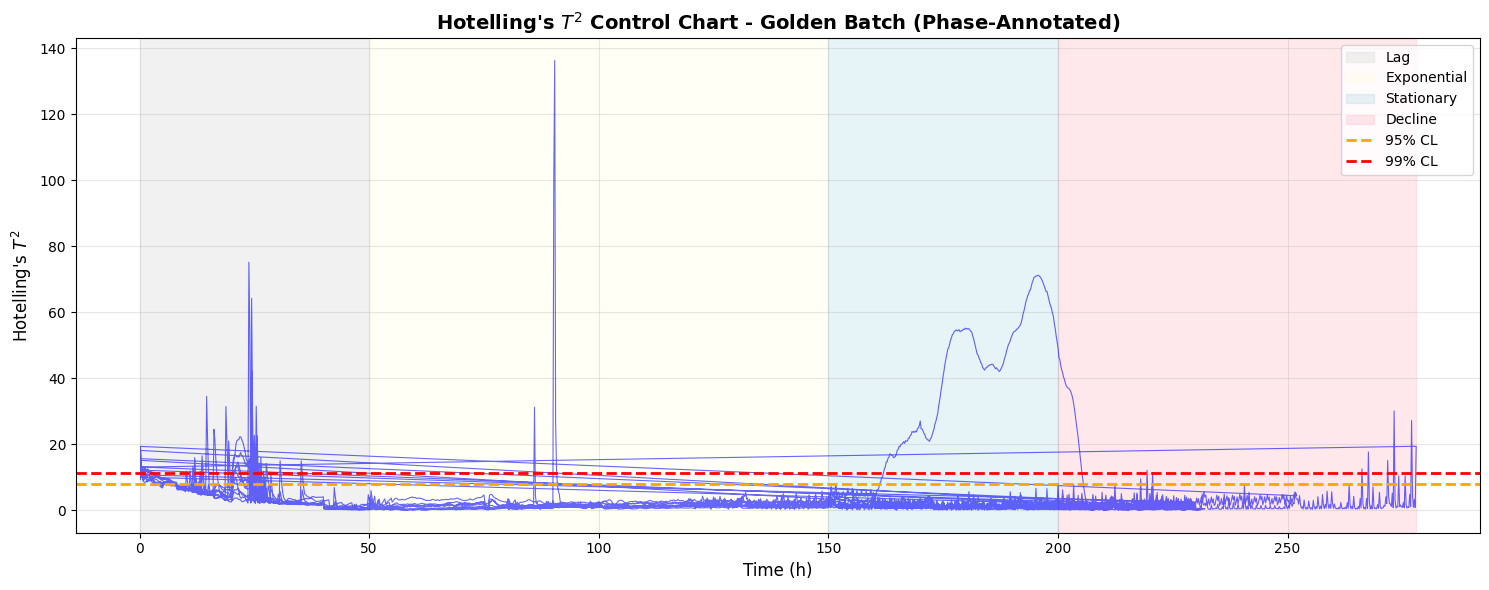

In [29]:
# Plot T^2 chart with phase overlays
plt.figure(figsize=(15, 6))

# Add phase background shading FIRST (so it's behind the data)
phase_regions = [
    ('Lag', 0, 50, 'lightgrey'),
    ('Exponential', 50, 150, 'lightyellow'),
    ('Stationary', 150, 200, 'lightblue'),
    ('Decline', 200, df_batch_1_10['Time (h)'].max(), 'lightpink')
]


for phase_name, start, end, color in phase_regions:
    plt.axvspan(start, end, color=color, alpha=0.3, label=phase_name)

# Plot T^2 values
plt.plot(df_batch_1_10['Time (h)'], df_batch_1_10['T2'], 'b-', alpha=0.6, linewidth=0.8)

# Add control limits
plt.axhline(y=ucl_95, color='orange', linestyle='--', linewidth=2, label='95% CL')
plt.axhline(y=ucl_99, color='red', linestyle='--', linewidth=2, label='99% CL')

plt.xlabel('Time (h)', fontsize=12)
plt.ylabel("Hotelling's $T^2$", fontsize=12)
plt.title("Hotelling's $T^2$ Control Chart - Golden Batch (Phase-Annotated)", 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./outputs/pca/hotelling_t2_chart_phases.png', dpi=300)
plt.show()

---
## 6. Conclusions

This project successfully established a comprehensive golden batch framework for industrial penicillin production using multivariate data analysis of 10 recipe-driven fermentation batches. The analysis demonstrates that modern Quality by Design (QbD) principles can be implemented through rigorous, data-driven process characterization.

**Key Achievements**
1. Golden Batch Definition:
The golden batch is defined not as a single ideal batch, but as a population-based multivariate reference that captures normal process behavior. This reference encompasses:
    - Phase-specific univariate operating envelopes for all critical parameters
    - A three-dimensional multivariate operating space (70.74% variance explained)
    - Reproducible temporal trajectories through PC space
    - Statistical control limits (Hotelling's $T^2$) for deviation detection.

2. Process Understanding:
Through systematic exploratory and multivariate analysis, this work has established:
    - Fermentation proceeds through four distinct phases with different metabolic and control characteristics
    - pH (5.00 ± 0.09) and Temperature (297.8 ± 0.01 K) are maintained under tight control throughout
    - Process behavior is governed by three dominant patterns: metabolic progression (PC1, 46%), oxygen balance (PC2, 14%), and environmental control (PC3, 11%)
    - Recipe-driven batches exhibit exceptional consistency

#### Future Applications
This project establishes the foundation for several advanced applications:
1. **Operator vs. Recipe Comparison (Batches 31-60):** 
    - Compare operator-controlled batches against the golden batch reference to quantify operator impact on process consistency and identify opportunities for automation or training.
2. **Advanced Process Control Evaluation (Batches 61-90):**
    - Assess whether APC strategies improve consistency, reduce variability, or enable operation closer to optimal trajectories compared to recipe-driven control.
3. **Fault Detection and Diagnosis (Batches 91-100):**
    - Develop multivariate fault detection models using the golden batch as the "normal" class and known-fault batches as "abnormal" classes. Train classifiers to detect and diagnose specific fault types based on PC trajectory deviations.
4. **Predictive Modeling:**
    - Use golden batch data to train models that predict final penicillin concentration, batch duration, or yield based on early-phase measurements, enabling adaptive control or early batch termination decisions.
5. **Real-Time Monitoring Dashboard:**
    - Implement live PC score calculation and T² monitoring in the manufacturing environment, providing operators with real-time visibility into multivariate process state relative to the golden batch reference.

# End